In [1]:
import numpy as np 
import pandas as pd
from sklearn.datasets import load_breast_cancer

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame

In [3]:
print(f'Data Shape: {df.shape[0]} Raw, {df.shape[1]} Columns')
print('\n ----- First 5 line -----')
display(df.head())

Data Shape: 569 Raw, 31 Columns

 ----- First 5 line -----


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
print('\n ----- Data Types -----')
print(df.info())

print('\n ------ Missing Value -----')
missing_value = df.isnull().sum()
print(missing_value[missing_value > 0])


 ----- Data Types -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  s

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train Boyutu: {X_train.shape} | y_train Boyutu: {y_train.shape}")
print(f"X_test Boyutu: {X_test.shape} | y_test Boyutu: {y_test.shape}")

X_train Boyutu: (455, 30) | y_train Boyutu: (455,)
X_test Boyutu: (114, 30) | y_test Boyutu: (114,)


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
    
print(f"===Sınıflandırma Başarısı ===")
print(f"Accuracy (Doğruluk Oranı): {acc:.4f}")
print("\nDetaylı Sınıflandırma Raporu:")  
print(classification_report(y_test, y_pred))
print("Karmaşıklık Matrisi (Confusion Matrix):")
print(confusion_matrix(y_test, y_pred))
print("-" * 40 + "\n")

===Sınıflandırma Başarısı ===
Accuracy (Doğruluk Oranı): 0.9649

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Karmaşıklık Matrisi (Confusion Matrix):
[[40  3]
 [ 1 70]]
----------------------------------------



In [9]:
y_prob = model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)

np.float64(0.9952505732066819)

In [7]:
from xgboost import XGBClassifier

model_x = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=2,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)
model_x.fit(X_train, y_train)
y_pred_x = model_x.predict(X_test)

acc = accuracy_score(y_test, y_pred_x)
    
print(f"===Sınıflandırma Başarısı ===")
print(f"Accuracy (Doğruluk Oranı): {acc:.4f}")

===Sınıflandırma Başarısı ===
Accuracy (Doğruluk Oranı): 0.9649


In [10]:
y_probx = model_x.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_probx)

np.float64(0.9898460530625615)

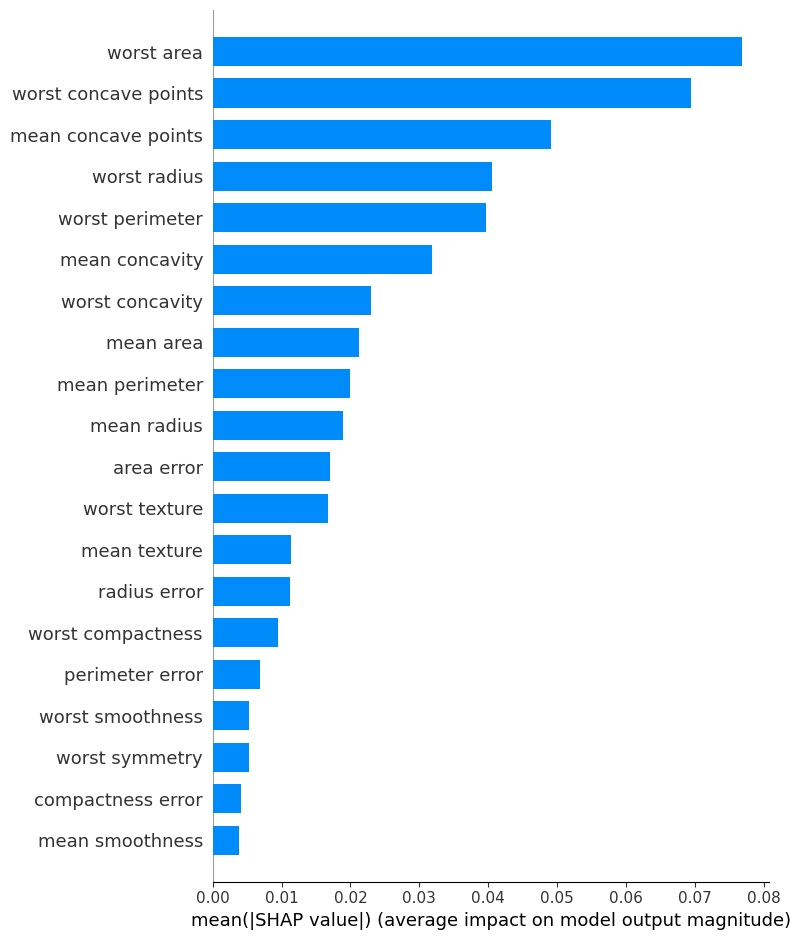

In [11]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    plot_type="bar"
)



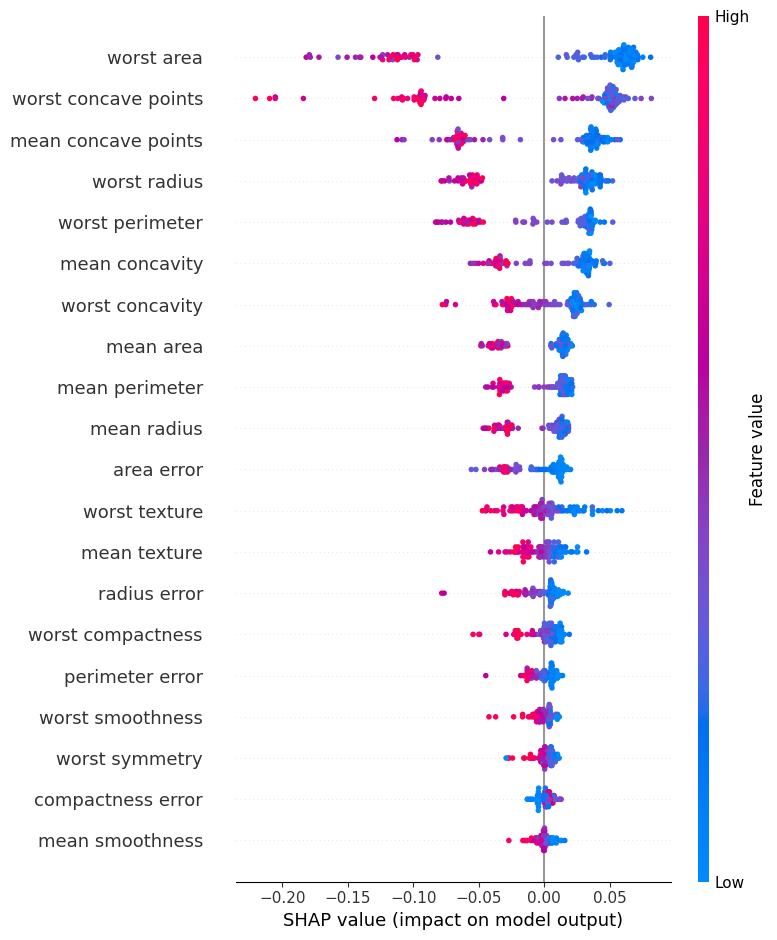

In [12]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)

Random Forest ve XGBoost modelleri karşılaştırılmıştır. Her iki model de benzer Accuracy değerleri üretmiştir. ROC-AUC açısından Random Forest küçük bir üstünlük göstermiştir. Bu durum, veri setinin yüksek ayrıştırılabilirliğe sahip olması ve daha karmaşık bir boosting yaklaşımının belirgin bir avantaj sağlamamasından kaynaklanabilir.

In [14]:
idx = np.random.randint(0, len(X_test))
print(f'seçilen gözlemin indexi : {idx}')
X_test.iloc[idx]

print("Gerçek sınıf :", y_test.iloc[idx])
print("Tahmin edilen :", model.predict(X_test.iloc[[idx]])[0])
print("Olasılıklar :", model.predict_proba(X_test.iloc[[idx]]))

seçilen gözlemin indexi : 76
Gerçek sınıf : 1
Tahmin edilen : 1
Olasılıklar : [[0.08 0.92]]


In [18]:
def explain_random_observation(model, X, class_index=1):

    idx = np.random.randint(0, len(X))

    print(f"Gözlem: {idx}")
    print()
    print(X.iloc[idx])

    print()
    print("Tahmin:", model.predict(X.iloc[[idx]])[0])
    print("Olasılık:", model.predict_proba(X.iloc[[idx]]))

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X)

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values.values[idx, :, class_index],
            base_values=shap_values.base_values[idx, class_index],
            data=X.iloc[idx],
            feature_names=X.columns
        )
    )

Gözlem: 58

mean radius                 13.480000
mean texture                20.820000
mean perimeter              88.400000
mean area                  559.200000
mean smoothness              0.101600
mean compactness             0.125500
mean concavity               0.106300
mean concave points          0.054390
mean symmetry                0.172000
mean fractal dimension       0.064190
radius error                 0.213000
texture error                0.591400
perimeter error              1.545000
area error                  18.520000
smoothness error             0.005367
compactness error            0.022390
concavity error              0.030490
concave points error         0.012620
symmetry error               0.013770
fractal dimension error      0.003187
worst radius                15.530000
worst texture               26.020000
worst perimeter            107.300000
worst area                 740.400000
worst smoothness             0.161000
worst compactness            0.422500


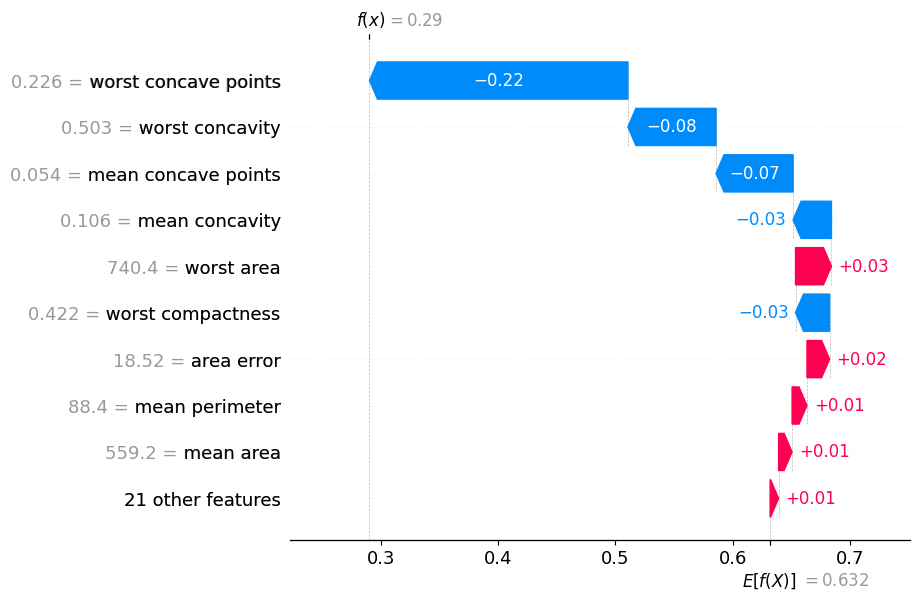

In [19]:
explain_random_observation(model, X_test, class_index=1)